# Assignment 5

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional notes:

* Please note that in this assignment, students are expected to work independently. As a result, no two solutions should look identical in terms of coding;
* You may import any libraries you need to complete the assignment. However, you must implement the model using TensorFlow (do not use PyTorch);
* Follow the same steps/idea as in Assignment 4; the difference here is that you extend a logistic model to more than two classes;
* <span style="color:chocolate"> Focus on the execution of the task rather than model performance </span> (this is how the TA will grade your work);
* Even though the prediction performance for your chosen outcome is low, it doesn't necessarily mean there is something wrong with your implementation. It could also be that the data is not supportive enough for your prediction task... again, focus on the learning opportunity and not the numbers you get;
* Your instructional team has extensive experience developing and running ML models. Often, we encounter situations where a model doesn't perform well on a predictive task. This can happen due to the nature of the data or the need for significant tweaking of variables to achieve good results;
* Do not spend significantly more time on this task than you did on Assignment 4, unless you wish to experiment and learn more.
---

``Objective``
* Perform multiclass classification using logistic regression. <span style="color:chocolate"> You will choose the outcome of interest. </span>

``Motivation``
* Chocolate is one of the most popular candies in the world. Each year, residents of the United States collectively eat more than 2.8 billions pounds (Source: Kaggle). However, not all chocolate bars are created equal! In this assignment, you will have the opportunity to delve into the world of chocolate by choosing your own machine learning task. 


``Data``

* The [Chocolate Bar dataset](https://www.kaggle.com/datasets/rtatman/chocolate-bar-ratings) contains expert ratings of 1,795 individual chocolate bars, along with information on their regional origin, percentage of cocoa, the variety of chocolate bean used and where the beans were grown (Source: Kaggle).

### Import libraries

In [1]:
%reset -f
from __future__ import print_function

import math
import numpy as np
import numpy.linalg as nla
import pandas as pd
import re
import six
from os.path import join
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from keras_tuner import HyperParameters
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# feel free to import other libraries as needed
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Define functions

In [2]:
def read_data():
    ''''''
    # Read data
    df = pd.read_csv(
        "https://download.mlcc.google.com/mledu-datasets/flavors_of_cacao.csv",
        sep=",",
        encoding='latin-1'
    )
    
    return df

In [3]:
def clean_data(df):
    ''''''
    # Set the output display to have one digit for decimal places and limit it to
    # printing 15 rows.
    pd.options.display.float_format = '{:.2f}'.format
    pd.options.display.max_rows = 15
    
    # Rename the columns.
    df.columns = [
        'maker', 'specific_origin', 'reference_number',
        'review_date', 'cocoa_percent', 'maker_location',
        'rating', 'bean_type', 'broad_origin'
    ]

    # df.dtypes

    # Replace empty/null values with "Blend"
    df['bean_type'] = df['bean_type'].fillna('Blend')

    # Cast bean_type to string to remove leading 'u'
    df['bean_type'] = df['bean_type'].astype(str)
    df['cocoa_percent'] = df['cocoa_percent'].str.strip('%')
    df['cocoa_percent'] = pd.to_numeric(df['cocoa_percent'])

    # Correct spelling mistakes, and replace city with country name
    df['maker_location'] = df['maker_location']\
    .str.replace('Amsterdam', 'Holland')\
    .str.replace('U.K.', 'England')\
    .str.replace('Niacragua', 'Nicaragua')\
    .str.replace('Domincan Republic', 'Dominican Republic')

    # Adding this so that Holland and Netherlands map to the same country.
    df['maker_location'] = df['maker_location']\
    .str.replace('Holland', 'Netherlands')

    def cleanup_spelling_abbrev(text):
        replacements = [
            ['-', ', '], ['/ ', ', '], ['/', ', '], ['\(', ', '], [' and', ', '], [' &', ', '], ['\)', ''],
            ['Dom Rep|DR|Domin Rep|Dominican Rep,|Domincan Republic', 'Dominican Republic'],
            ['Mad,|Mad$', 'Madagascar, '],
            ['PNG', 'Papua New Guinea, '],
            ['Guat,|Guat$', 'Guatemala, '],
            ['Ven,|Ven$|Venez,|Venez$', 'Venezuela, '],
            ['Ecu,|Ecu$|Ecuad,|Ecuad$', 'Ecuador, '],
            ['Nic,|Nic$', 'Nicaragua, '],
            ['Cost Rica', 'Costa Rica'],
            ['Mex,|Mex$', 'Mexico, '],
            ['Jam,|Jam$', 'Jamaica, '],
            ['Haw,|Haw$', 'Hawaii, '],
            ['Gre,|Gre$', 'Grenada, '],
            ['Tri,|Tri$', 'Trinidad, '],
            ['C Am', 'Central America'],
            ['S America', 'South America'],
            [', $', ''], [',  ', ', '], [', ,', ', '], ['\xa0', ' '],[',\s+', ','],
            [' Bali', ',Bali']
        ]
        for i, j in replacements:
            text = re.sub(i, j, text)
        return text

    df['specific_origin'] = df['specific_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Cast specific_origin to string
    df['specific_origin'] = df['specific_origin'].astype(str)

    # Replace null-valued fields with the same value as for specific_origin
    df['broad_origin'] = df['broad_origin'].fillna(df['specific_origin'])

    # Clean up spelling mistakes and deal with abbreviations
    df['broad_origin'] = df['broad_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Change 'Trinitario, Criollo' to "Criollo, Trinitario"
    # Check with df['bean_type'].unique()
    df.loc[df['bean_type'].isin(['Trinitario, Criollo']),'bean_type'] = "Criollo, Trinitario"
    # Confirm with df[df['bean_type'].isin(['Trinitario, Criollo'])]

    # Fix chocolate maker names
    df.loc[df['maker']=='Shattel','maker'] = 'Shattell'
    df['maker'] = df['maker'].str.replace(u'Na\xef\xbf\xbdve','Naive')

    return df

---
### Step 1: Data ingestion

First, we'll initiate the process of discovering the chocolate world by loading the data. Then, to assist with this assignment, we'll start by tidying up the data a little bit. This involves renaming columns and conducting some string preprocessing tasks, which will be handled by the <span style="color:chocolate">clean_data()</span> function mentioned earlier.

In [4]:
df = clean_data(read_data())
print('Shape of data', df.shape)
df.head()

Shape of data (1795, 9)


,maker,specific_origin,reference_number,review_date,cocoa_percent,maker_location,rating,bean_type,broad_origin
0,A. Morin,Agua Grande,1876,2016,63.00,France,3.75,Blend,Sao Tome
1,A. Morin,Kpime,1676,2015,70.00,France,2.75,Blend,Togo
2,A. Morin,Atsane,1676,2015,70.00,France,3.00,Blend,Togo
3,A. Morin,Akata,1680,2015,70.00,France,3.50,Blend,Togo
4,A. Morin,Quilla,1704,2015,70.00,France,3.50,Blend,Peru


### <span style="color:chocolate">Exercise 1:</span> Getting to know the data (5 points)

Answer the following questions:
    
1. How many columns does the dataset contain?
2. How many rows are there in the dataset?
3. What are the column names?
4. List the number of unique values for each column in the data;
5. What are the unique cocoa_percent values?

In [5]:
# YOUR CODE HERE
print(df.shape)
print('1). There are 9 columns')
print('2). There are 1795 rows')

print('3). The column names are: ')
print(*df.columns.values)

print('4). Unique values for each column')
print(df.nunique())

print('5). The unique values represent what percent cocoa each chocolate is. \nHere are the unique values')
print(*np.sort(df.cocoa_percent.unique()))





(1795, 9)
1). There are 9 columns
2). There are 1795 rows
3). The column names are: 
maker specific_origin reference_number review_date cocoa_percent maker_location rating bean_type broad_origin
4). Unique values for each column
maker                414
specific_origin     1038
reference_number     440
review_date           12
cocoa_percent         45
maker_location        58
rating                13
bean_type             39
broad_origin         160
dtype: int64
5). The unique values represent what percent cocoa each chocolate is. 
Here are the unique values
42.0 46.0 50.0 53.0 55.0 56.0 57.0 58.0 60.0 60.5 61.0 62.0 63.0 64.0 65.0 66.0 67.0 68.0 69.0 70.0 71.0 72.0 72.5 73.0 73.5 74.0 75.0 76.0 77.0 78.0 79.0 80.0 81.0 82.0 83.0 84.0 85.0 86.0 87.0 88.0 89.0 90.0 91.0 99.0 100.0


### <span style="color:chocolate">Exercise 2:</span> Choosing the prediction task (5 points)

Now that you’ve explored the data, choose a multiclass outcome (anything except "ratings") that you’re interested in predicting. Note: The outcome should have <span style="color:chocolate">at least 3 classes</span>!

If your chosen outcome variable requires preprocessing, go ahead and handle that below. For instance, you might choose to predict "cocoa_percent". Discretizing it into "0=low," "1=medium," and "2=high" makes it easier to work with/interpret the results.

Your answer here: 

use cocoa percent, and bin it into groups of 20%
cocoa_pct_binned
1    1610
2     111
0      74
Name: count, dtype: int64


(array([  74.,    0.,    0.,    0.,    0., 1610.,    0.,    0.,    0.,
         111.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

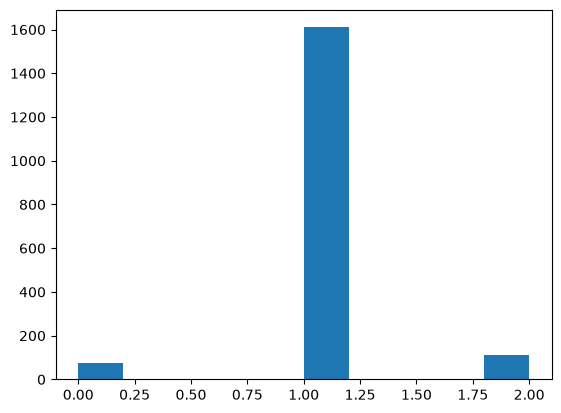

In [6]:
# YOUR CODE HERE
# plt.hist(df.cocoa_percent)

print('use cocoa percent, and bin it into groups of 20%')
df['cocoa_pct_binned'] = pd.cut(df.cocoa_percent, bins = [40,60,80,100],labels = [0,1,2])

print(df.cocoa_pct_binned.value_counts())
plt.hist(df.cocoa_pct_binned)

---
### Step 2: Data preprocessing

### <span style="color:chocolate">Exercise 3:</span> Prepare data for modeling (20 points)

Following the format of previous assignments, adhere to the following steps as a minimum:

1. Shuffle the dataset;
2. Create training, validation, and test datasets using a 60/20/20 split;
3. Identify the features of interest;
4. Perform necessary cleaning and standarization on the features.

In [7]:
# YOUR CODE HERE
np.random.seed(0)

# shuffle it
indices = np.arange(df.shape[0])
shuffled_indices = np.random.permutation(indices)
df_shuffled = df.reindex(shuffled_indices)

In [8]:
# split test train set
df_train, df_test_temp = train_test_split(df_shuffled, train_size = 0.6)
df_val, df_test = train_test_split(df_test_temp, train_size = 0.5)

print(df_train.shape)
print(df_val.shape)
print(df_test.shape)

df_train.dtypes

# plt.hist(df_train.reference_number)
# counts = df_train.groupby('reference_number')['cocoa_pct_binned'].nunique()
# counts[counts ==2]
# # it is not collinear, but MOST reference numbers are collinear, remove that

(1077, 10)
(359, 10)
(359, 10)


maker                    str
specific_origin          str
reference_number       int64
review_date            int64
cocoa_percent        float64
maker_location           str
rating               float64
bean_type                str
broad_origin             str
cocoa_pct_binned    category
dtype: object

Remove maker location since all of the information is stored in maker. I will not use specific_origin, reference number, and review date because it is likely too granular, and therefore would not be able to contribute well to the model.

In [9]:
# remove some feature options
X_train = df_train[['maker','broad_origin','bean_type','rating']]
X_test = df_test[['maker','broad_origin','bean_type','rating']]
X_val = df_val[['maker','broad_origin','bean_type','rating']]

# one hot encoding for maker, broad origin, and bean type
categorical_cols = ['maker', 'broad_origin', 'bean_type']

# one-hot encode each split
X_train_cat = pd.get_dummies(X_train[categorical_cols])
X_val_cat   = pd.get_dummies(X_val[categorical_cols])
X_test_cat  = pd.get_dummies(X_test[categorical_cols])

# align test columns to match train filling missing w a 0
X_val_cat  = X_val_cat.reindex(columns=X_train_cat.columns, fill_value=0)
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

rating_mean = X_train['rating'].mean()
rating_std = X_train['rating'].std()

rating_train_scaled = (X_train['rating'] - rating_mean) / rating_std
rating_val_scaled = (X_val['rating'] - rating_mean) / rating_std
rating_test_scaled = (X_test['rating'] - rating_mean) / rating_std

X_train_final = pd.concat([
    X_train_cat.reset_index(drop=True),
    rating_train_scaled.reset_index(drop=True)
    ], axis=1)

X_val_final = pd.concat([
    X_val_cat.reset_index(drop=True),
    rating_val_scaled.reset_index(drop=True)
    ], axis=1)

X_test_final = pd.concat([
    X_test_cat.reset_index(drop=True),
    rating_test_scaled.reset_index(drop=True)
    ], axis=1)

# create Y train, test, val
Y_train = df_train['cocoa_pct_binned']
Y_test = df_test['cocoa_pct_binned']
Y_val = df_val['cocoa_pct_binned']



---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 4:</span> Plots (20 points)

In line with the structure of previous assignments, execute the following steps:

1. Generate a minimum of 4 plots to investigate features and outcome within the training dataset;
2. Ensure that each plot includes clear axis labels and titles;
3. Provide commentary on the insights learned from your visualizations.

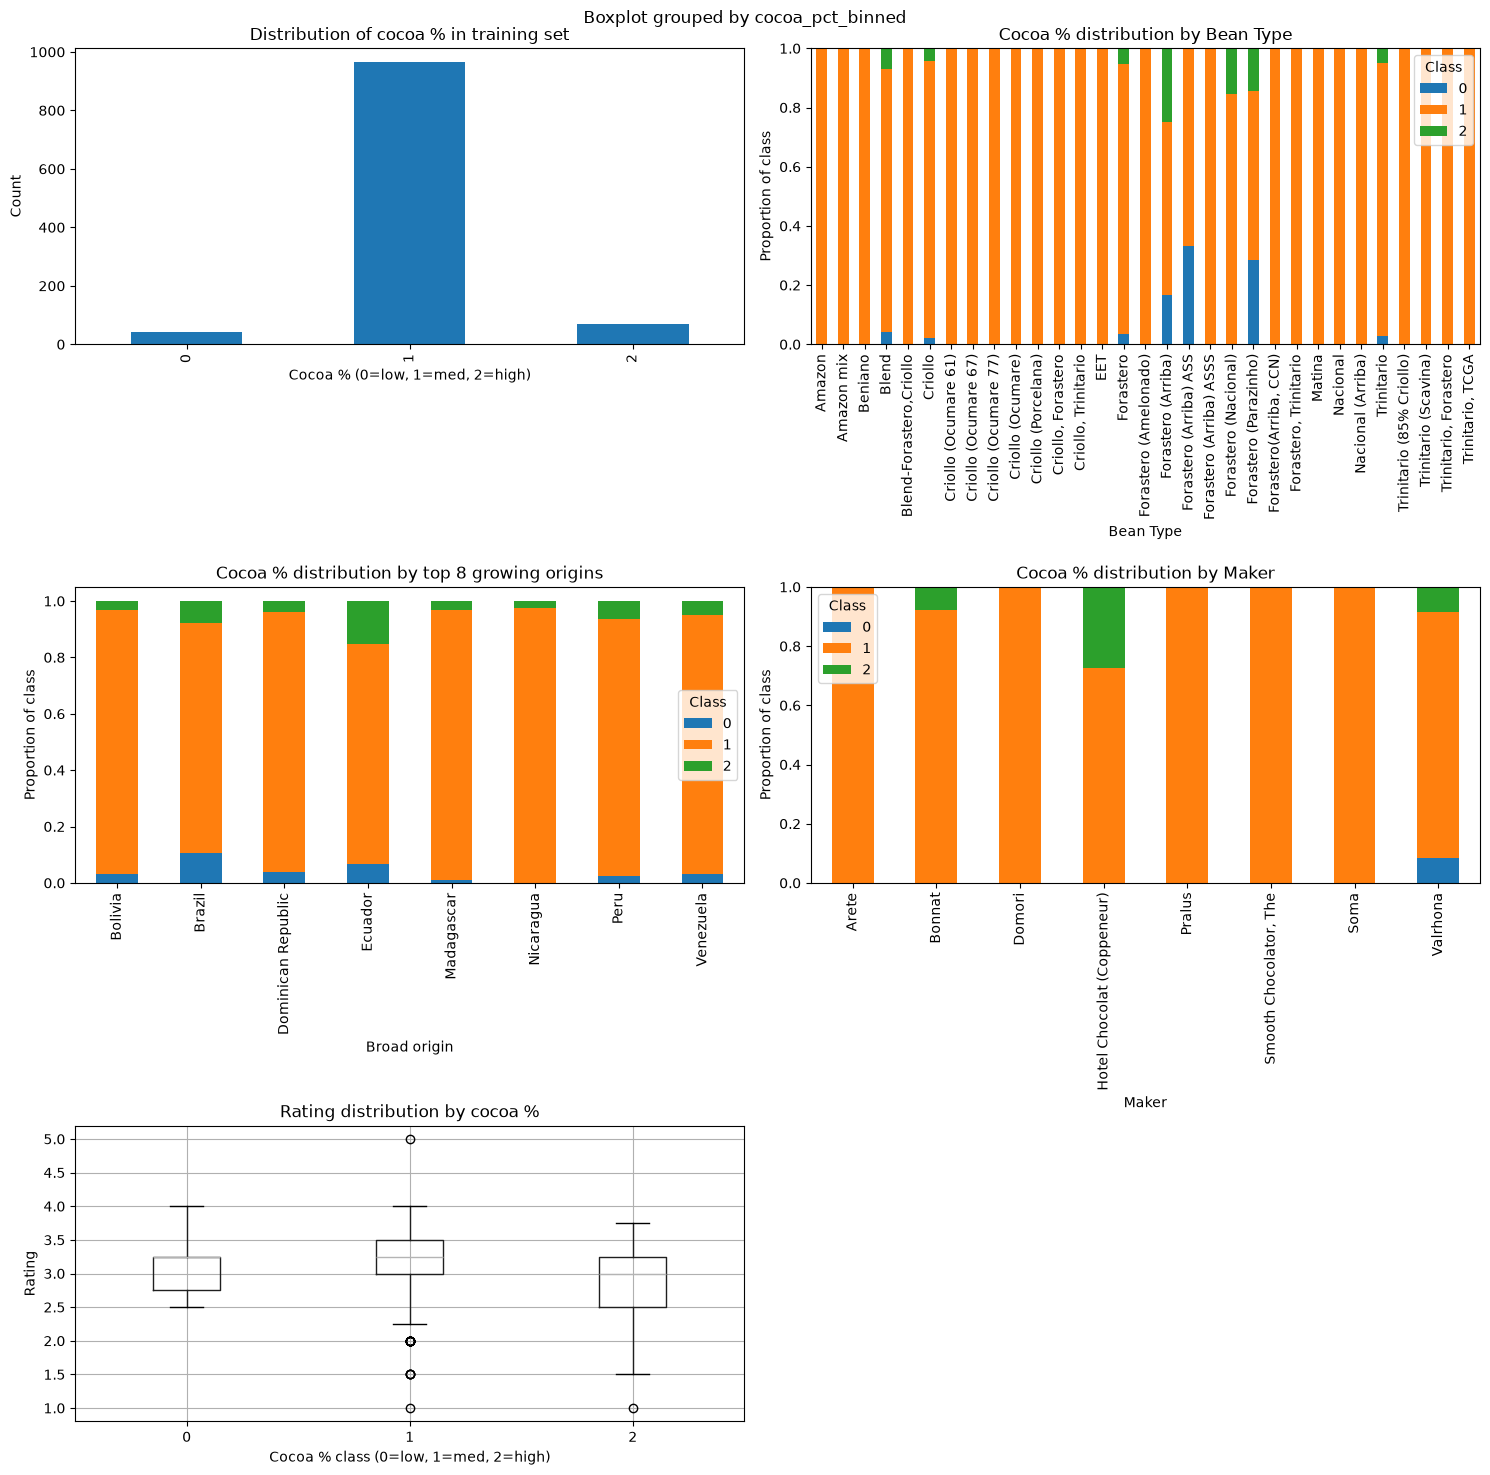

In [10]:
# YOUR CODE HERE
# going to need to bring the one hots back to dense probably
fig, ax = plt.subplots(3,2,figsize=(15,15))

Y_train.value_counts().sort_index().plot(kind='bar', ax=ax[0, 0])

ax[0,0].set_xlabel('Cocoa % (0=low, 1=med, 2=high)')
ax[0,0].set_ylabel('Count')
ax[0,0].set_title('Distribution of cocoa % in training set')


# Origins
top_origins = df_train['broad_origin'].value_counts().nlargest(8).index
subset = df_train[df_train['broad_origin'].isin(top_origins)]
ct = pd.crosstab(subset['broad_origin'], subset['cocoa_pct_binned'], normalize='index')

ct.plot(kind='bar', stacked=True, ax=ax[1,0])
ax[1,0].set_xlabel('Broad origin')
ax[1,0].set_ylabel('Proportion of class')
ax[1,0].set_title('Cocoa % distribution by top 8 growing origins')
ax[1,0].legend(title='Class')
plt.xticks(rotation=45, ha='right')


# bean type
ct = pd.crosstab(df_train['bean_type'], df_train['cocoa_pct_binned'], normalize='index')

ct.plot(kind='bar', stacked=True, ax=ax[0,1])
ax[0,1].set_xlabel('Bean Type')
ax[0,1].set_ylabel('Proportion of class')
ax[0,1].set_title('Cocoa % distribution by Bean Type')
ax[0,1].legend(title='Class')

# bean type
top_maker = df_train['maker'].value_counts().nlargest(8).index
subset = df_train[df_train['maker'].isin(top_maker)]
ct = pd.crosstab(subset['maker'], subset['cocoa_pct_binned'], normalize='index')

ct.plot(kind='bar', stacked=True, ax=ax[1,1])
ax[1,1].set_xlabel('Maker')
ax[1,1].set_ylabel('Proportion of class')
ax[1,1].set_title('Cocoa % distribution by Maker')
ax[1,1].legend(title='Class')

df_train.boxplot(column='rating', by='cocoa_pct_binned', ax=ax[2,0])
ax[2,0].set_xlabel('Cocoa % class (0=low, 1=med, 2=high)')
ax[2,0].set_ylabel('Rating')
ax[2,0].set_title('Rating distribution by cocoa %')
ax[2,1].axis('off') 

plt.tight_layout()

It is hard to gather from these charts if there are trends that will help the model predict accurately. Because there is such an skewed proportion of the outcome variable, it looks like it dominates every subcategory. However, this skewed majority class will be a good baseline since it is such a high percentage. There do seem to be a few bean types and makers that stray from this super high skew which will be helpful in predicting which class it is in besides class 1. 

---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 5:</span> Baseline model (10 points)

When dealing with classification problems, a simple baseline is to select the *majority* class (the most common label in the training set) and use it as the prediction for all inputs.

1. Implement this baseline and report the accuracy metric on the train data;

2. Implement a function that computes the Log Loss (cross-entropy loss) metric and use it to evaluate this baseline on both the train and validation data. Note: reflect on what you know about the original distribution of classes in your training data (Hint: see Assignment 4 - Exercise 8 and ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example).

In [11]:
## COPIED FROM LECTURE - CROSS ENTROPY LOSS FUNCTION
def ce_loss(preds, Y):
  
  m = Y.shape[0]
  ## MUST CHANGE IT TO CLIPPED VERSION, TOO MANY 0's ARE CAUSE IT TO GO TO INFINITY
  preds_true_class = np.clip(preds[np.arange(m), Y], 1e-15, 1 - 1e-15)
  cross_entropy_values = -np.log(preds_true_class)
  loss = np.sum(cross_entropy_values) / m

  return loss

In [12]:
# define the baseline, all predictions are majority class (Y == 1)
baseline_accuracy = np.sum(Y_train == 1)/Y_train.shape

baseline_predics = np.zeros(shape = (Y_train.shape[0],3)) # want this to be [0,1,0] for every row, already in softmax form here
baseline_predics[:,1] = np.ones(shape = (Y_train.shape[0]))

basepred_val = np.zeros(shape = (Y_val.shape[0],3))
basepred_val[:,1] = np.ones(shape = (Y_val.shape[0]))

baseline_loss_train = ce_loss(baseline_predics,Y_train)
baseline_loss_val = ce_loss(basepred_val,Y_val)

print(f'Baseline Loss (Train Data): {baseline_loss_train}')
print(f'Baseline Loss (Validation Data): {baseline_loss_val}')

print(f'Baseline Accuracy: {baseline_accuracy}')


Baseline Loss (Train Data): 3.623845619893136
Baseline Loss (Validation Data): 3.5597067593640546
Baseline Accuracy: [0.89507892]


The cross entropy loss function had to be modified from the form given in class because it was not equiped to handle zeros with the np.log function. instead, they were treated to be 1e-15 (nearly zero) so that they would not make it go to infinity. 

Since the majority class makes up such a large part of the sample size, the baseline loss is only 3.62 on the train data, and 3.56 for the validation data. This shows good generalization for the baseline model. The accuracy here represents the proportion of the majority class which is the medium cocoa ratio, which appears to take up nearly 90% of the data.

### <span style="color:chocolate">Exercise 6:</span> Improvement over baseline with Tensorflow (10 points)

Use TensorFlow (TF) to train a multiclass logistic regression model much like you did in Assignment 4. The goal here is to build a ML model to improve over the baseline classifier. You have the flexibility to choose which features to include.

With this in mind, complete the following tasks:

1. Build and compile a multiclass classification TF model (call it model_tf). Hint: the activation function, the loss, and the evaluation metric are different compared to the binary logistic regression (see ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example). Set learning_rate = 0.0001 and optimizer = SGD.
2. Train model_tf using the training dataset and pass the validation data for validation. Set num_epochs = 10 and batch_size = 32.
3. Generate a plot (for the training and validation data) with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title.

If instructions for any other hyperparameters are not provided here, you are free to select your own or use the default settings.

In [13]:
# YOUR CODE HERE
## COPIED FROM CLASS NOTES

def build_model(learning_rate,num_features, num_classes):
    '''
    Input: learning rate, number of features, number of output classes
    Output: Model

    Other parameters: 
     - SGD as optimizer
     - softmax activation
     - use bias, we dont automatically ahve the 1's built in
    '''
        
    tf.keras.backend.clear_session()
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Dense(
        units=num_classes,                     # output dim
        input_shape=[num_features],             # input dim
        use_bias=True,             
        activation='softmax'        
        # kernel_initializer=tf.ones_initializer,  # initialize params to 1
    ))

    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=optimizer,
        metrics=['accuracy'])

    return model



Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1588 - loss: 1.1340 - val_accuracy: 0.1309 - val_loss: 1.1413
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - accuracy: 0.1634 - loss: 1.1316 - val_accuracy: 0.1393 - val_loss: 1.1388
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - accuracy: 0.1662 - loss: 1.1292 - val_accuracy: 0.1393 - val_loss: 1.1364
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - accuracy: 0.1699 - loss: 1.1269 - val_accuracy: 0.1476 - val_loss: 1.1340
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - accuracy: 0.1764 - loss: 1.1245 - val_accuracy: 0.1504 - val_loss: 1.1316
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - accuracy: 0.1820 - loss: 1.1221 - val_accuracy: 0.1532 - val_loss: 1.1291
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - accuracy: 0.1885 - loss: 1.1198 - val_accuracy: 0.1643 - val_loss: 1.1267
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - accuracy: 0.1950 - loss: 1.1174 - val_accuracy: 0.17

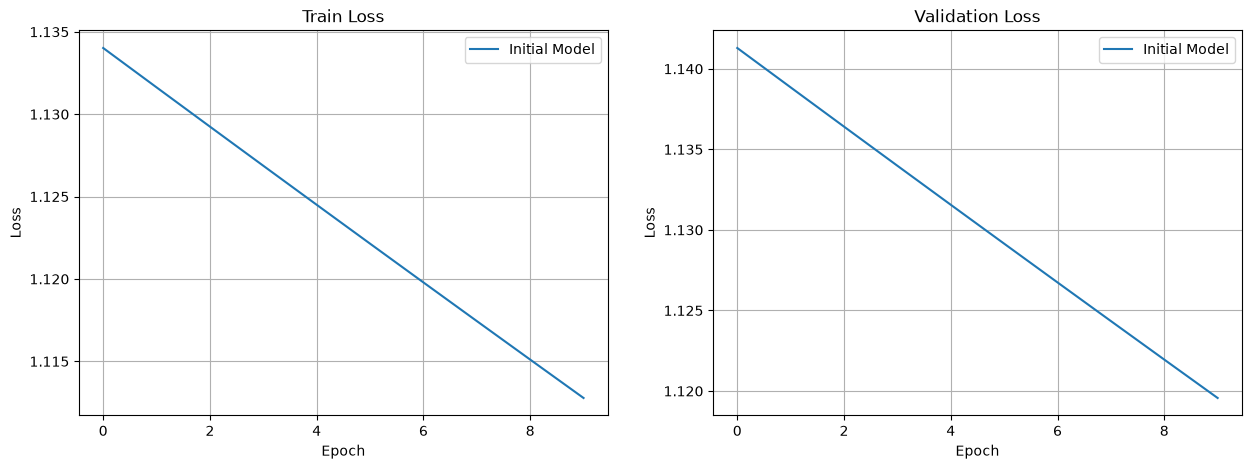

In [14]:
## plot model function
tf.random.set_seed(0)

# make them non categoricals
y_train = Y_train.astype(int).values
y_val = Y_val.astype(int).values
y_test = Y_test.astype(int).values

model_tf = build_model(
    num_features=X_train_final.shape[1],
    learning_rate=0.0001,
    num_classes = 3)

# 3. Fit the model
model_tf_fit = model_tf.fit(
    x = X_train_final,
    y = y_train,
    validation_data = (X_val_final,y_val),
    epochs = 10,
    batch_size = 32
)

# 4. Generate (1,2) plot
def plot_loss(model_plot,label_loss):
    
    axes[0].plot(model_plot.history['loss'], label=label_loss)
    axes[1].plot(model_plot.history['val_loss'], label=label_loss) # val_loss is the validation/test data
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Train Loss')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss')
    axes[1].grid(True)
    axes[1].legend()


fig,axes = plt.subplots(1,2,figsize=(15,5))

plot_loss(model_tf_fit,'Initial Model')

The hyperparameters clearly need to be tuned, it has not converged yet

---
### Step 5: Hyperparameter tuning

### <span style="color:chocolate">Exercise 7:</span> Choosing hyperparameters (10 points)

1. Fine-tune the **learning rate**, **number of epochs**, and **batch size** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). 

After identifying your preferred model configuration, print the following information:

2. The first five learned parameters of the model (this should include the bias term);
3. The loss at the final epoch on both the training and validation datasets;
4. The percentage difference between the losses observed on the training and validation datasets.
5. Compare the training/validation loss of the TensorFlow model (model_tf) with the baseline model's loss. Does the TensorFlow model demonstrate an improvement over the baseline model?

Choosing epochs = 100 and learning rate = 0.01. This way the validation loss is still similar to the train loss (generalizing well) and the loss is low


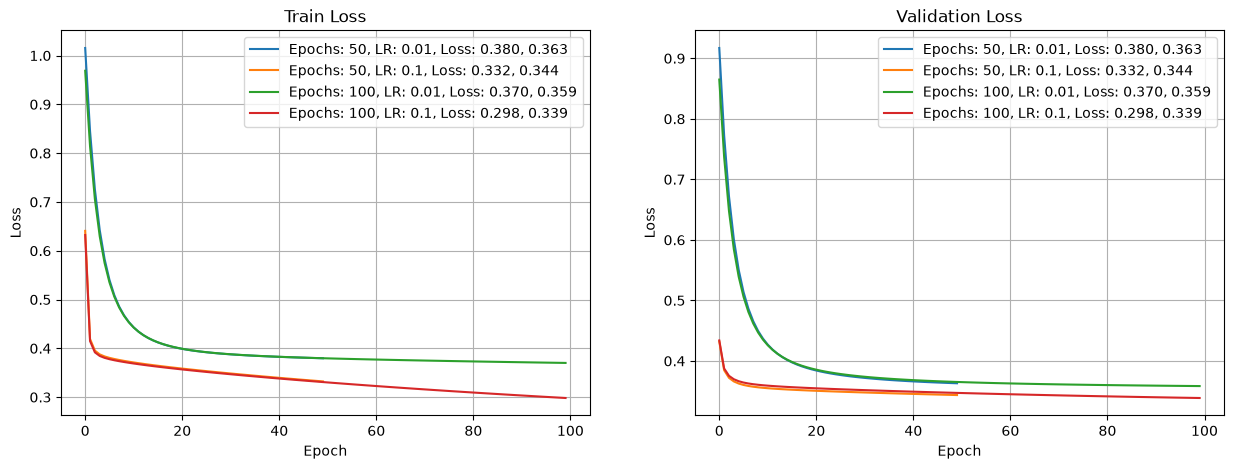

In [15]:
# YOUR CODE HERE

# hyperparameter tuning
tf.random.set_seed(0)

fig,axes = plt.subplots(1,2,figsize=(15,5))

epochs = 5
learning_rate = 0.01
for epochs in [50,100]:
    for learning_rate in [0.01,0.1]:
    
        model_tf = build_model(num_features=X_train_final.shape[1],learning_rate=learning_rate, num_classes=3)

        model_tf_fit = model_tf.fit(
            x = X_train_final,
            y = y_train,
            validation_data = (X_val_final,y_val),
            verbose = 0,
            epochs = epochs,
            batch_size = 32
        )

        plot_loss(model_tf_fit,label_loss = f'Epochs: {epochs}, LR: {learning_rate}, Loss: {model_tf_fit.history["loss"][-1]:.3f}, {model_tf_fit.history["val_loss"][-1]:.3f}')

final_epochs = 100
final_learning_rate = 0.01

print('Choosing epochs = 100 and learning rate = 0.01. This way the validation loss is still similar to the train loss (generalizing well) and the loss is low')

In [16]:
## Plot final model and get weights
model_tf_fin = build_model(num_features=X_train_final.shape[1],learning_rate=final_learning_rate, num_classes=3)

model_tf_fit_fin = model_tf_fin.fit(
    x = X_train_final,
    y = y_train,
    validation_data = (X_val_final,y_val),
    verbose = 0,
    epochs = final_epochs,
    batch_size = 32
)

print(f'1. Final Model Hyperparameters: Learning rate = {final_learning_rate}, Epochs = {final_epochs}')
print('2. First 5 Learned Parameters:')
weights, bias = model_tf_fin.get_weights()
print(f'    Bias: {bias}')
print(f'    Next 5 Parameters: {weights.flatten()[:5]}')


print(f'3. Loss at Final Epoch: Train Loss = {model_tf_fit_fin.history["loss"][-1]:.3f}, Validation Loss = {model_tf_fit_fin.history["val_loss"][-1]:.3f}')
print(f'''4. % Diff in Train and Val Loss = {(model_tf_fit_fin.history["loss"][-1] - model_tf_fit_fin.history["val_loss"][-1])/
 ((model_tf_fit_fin.history["loss"][-1] +model_tf_fit_fin.history["val_loss"][-1])/2)*100:.3f}%''')
print(' (The percent difference used average of the two losses as a denominator)')
print(f'5. Baseline Model Loss: Train Loss = {baseline_loss_train:.3f}, Val Loss = {baseline_loss_val:.3f}')
print(' This is much higher than the loss from the tensorflow model, so the tensorflow model has minimized loss')


1. Final Model Hyperparameters: Learning rate = 0.01, Epochs = 100
2. First 5 Learned Parameters:
    Bias: [-0.8629288  1.5210147 -0.6580818]
    Next 5 Parameters: [-0.12226392  0.01225339  0.05353689  0.13650964 -0.09598465]
3. Loss at Final Epoch: Train Loss = 0.369, Validation Loss = 0.356
4. % Diff in Train and Val Loss = 3.586%
 (The percent difference used average of the two losses as a denominator)
5. Baseline Model Loss: Train Loss = 3.624, Val Loss = 3.560
 This is much higher than the loss from the tensorflow model, so the tensorflow model has minimized loss


---
### Step 6: Evaluation and generalization

### <span style="color:chocolate">Exercise 8:</span> Compute metrics (10 points)

Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

1. Calculate aggregate accuracy on both train and test datasets. Note: you will need to convert the vector of predicted probabilities to a class label using the argmax operation. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method provided by tf.keras. and the <span style="color:chocolate">np.max()</span> method available in NumPy.

2. Does the model demonstrate strong aggregate generalization capabilities? Provide an explanation based on your accuracy observations.

In [17]:
# YOUR CODE HERE
train_preds_prob = model_tf_fin.predict(X_train_final, verbose = 0)
test_preds_prob = model_tf_fin.predict(X_test_final,verbose = 0)

# change this from probabilities to which is the highest index
train_preds = np.argmax(train_preds_prob, axis=1)
test_preds = np.argmax(test_preds_prob, axis=1)

train_accuracy = np.mean(train_preds == y_train)
test_accuracy = np.mean(test_preds == y_test)

print(f'Train accuracy: {train_accuracy}')
print(f'Test accuracy: {test_accuracy}')



Train accuracy: 0.8969359331476323
Test accuracy: 0.8969359331476323


The test and train accuracy is the exact same, which is very similar to the baseline accuracy with only slight improvement. While this shows strong accuracy for both the test and train, it seems like the model defaulted to predicting the majority class for almost every prediction. This will be explored more in the next exercise

### <span style="color:chocolate">Exercise 9:</span> Additional metrics (10 points)

Using the test dataset:

1. Plot the confusion matrix. Identify which class the model confuses the most.

2. Determine which class has the lowest precision. What is the precision? Which class is the largest source of false positives?

3. Determine which class has the lowest recall. What is the recall? Which class is the largest source of false negatives?

Text(0.5, 1.0, 'Confusion matrix on test set')

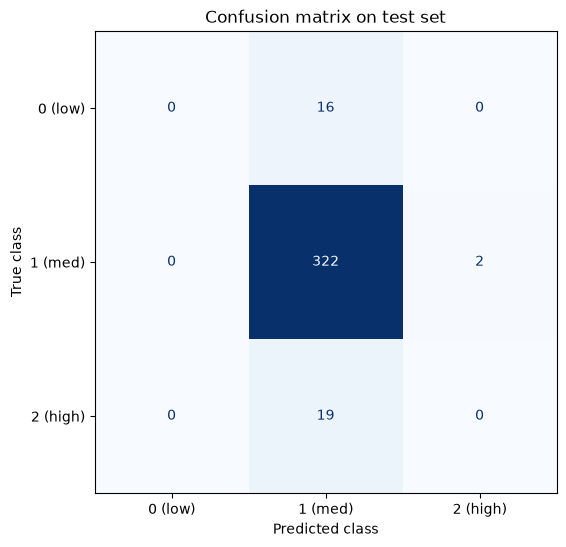

In [18]:
# YOUR CODE HERE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_preds)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0 (low)', '1 (med)', '2 (high)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title('Confusion matrix on test set')

In [19]:
print('Precision:')
print(f'    Class 1: {322/357:.3f}')
print(f'    Class 2: {0/2:.3f}')
print(f'    Class 0: 0/0 AKA undefined')

print('Recall:')
print(f'    Class 1: {322/324:.3f}')
print(f'    Class 2: {0/19:.3f}')
print(f'    Class 0: {0/16:.3f}')


Precision:
    Class 1: 0.902
    Class 2: 0.000
    Class 0: 0/0 AKA undefined
Recall:
    Class 1: 0.994
    Class 2: 0.000
    Class 0: 0.000


1. The model confuses class 2 the most because it predicted it twice (both incorrectly), but it occurred 19 times. 
2. Which class has the lowest precision?
    
    Class 2 has the lowest precision because of the times it was predicted (2 times), both were wrong. Class 0 also has bad preicion, but it is undefined since it was predicted 0 times.
    The largest source of false positives is class one, since both positive predictions of class 2 were actually class 1.
3. Which class had lowest recall and false negatives?
    
    Class 0 and class 2 both have low recall because of the true occurances of class 0 and 2 (16 and 19 respectively), it was correctly predicted 0 times for both yielding recall of 0%
    The largest source of false negatives is class 1. All of the predictions that did not go to class 0 and 2 when they should have went to class 1.

The model predicts class 1 almost every time, which makes sense because it is so heavily skewed outcome weighted towards class 1.


----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Following the approach in Assignment 4 - Exercise 12, evaluate whether your model shows any signs of unfairness. Explain your findings and propose suggestions for improvement.

The model shows extreme unfairness because it pretty much predicts class 1 every time, which is the baseline model. This could be improved by downsampling the majority class or by creating synthetic data for the two non majority classes.

In [20]:
# YOUR CODE HERE